# 🛒 Exploratory Data Analysis – Global Superstore Dataset
**Author:** Ashish Sharma  
**Dataset:** 51,000+ retail transactions (2020–2024)  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Jupyter Notebook  
**GitHub:** [github.com/ashishsharma](https://github.com/ashishsharma)

---
### Objectives
1. Understand dataset structure, distributions, and data quality
2. Identify profitability drivers across categories, regions, and segments
3. Analyse seasonality and time-series sales trends
4. Uncover loss-making sub-categories and shipping cost patterns
5. Provide data-backed business recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('../data/global_superstore.csv', parse_dates=['Order_Date', 'Ship_Date'])
print(f"Shape: {df.shape}")
df.head()


Shape: (51000, 15)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Segment,Country,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,1,CA-2023-100000,2020-09-29,2020-10-03,Second Class,CG-10543,Consumer,United States,East,Furniture,Furnishings,8300.50,5,0.5,587.90
1,2,CA-2021-100001,2022-05-13,2022-05-22,Standard Class,CG-10382,Home Office,United States,South,Office Supplies,Appliances,5269.95,10,0.3,304.93
2,3,CA-2024-100002,2023-03-07,2023-03-08,Same Day,CG-10693,Consumer,China,East,Furniture,Tables,3808.98,2,0.5,373.15
3,4,CA-2022-100003,2023-02-16,2023-02-16,Same Day,CG-10547,Corporate,United States,Central,Technology,Copiers,26833.52,7,0.0,4275.63
4,5,CA-2021-100004,2022-01-02,2022-01-06,Second Class,CG-10765,Home Office,United States,South,Technology,Copiers,17368.78,4,0.5,2629.03


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row_ID        51000 non-null  int64         
 1   Order_ID      51000 non-null  str           
 2   Order_Date    51000 non-null  datetime64[us]
 3   Ship_Date     51000 non-null  datetime64[us]
 4   Ship_Mode     51000 non-null  str           
 5   Customer_ID   51000 non-null  str           
 6   Segment       51000 non-null  str           
 7   Country       51000 non-null  str           
 8   Region        51000 non-null  str           
 9   Category      51000 non-null  str           
 10  Sub_Category  51000 non-null  str           
 11  Sales         51000 non-null  float64       
 12  Quantity      51000 non-null  int64         
 13  Discount      51000 non-null  float64       
 14  Profit        51000 non-null  float64       
dtypes: datetime64[us](2), float64(3), int64(2), str

In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")


=== Missing Values ===
Row_ID          0
Order_ID        0
Order_Date      0
Ship_Date       0
Ship_Mode       0
Customer_ID     0
Segment         0
Country         0
Region          0
Category        0
Sub_Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64



Duplicates: 0


In [5]:
df.describe().round(2)


,Row_ID,Order_Date,Ship_Date,Sales,Quantity,Discount,Profit
count,51000.00,51000,51000,51000.00,51000.00,51000.00,51000.00
mean,25500.50,2021-12-28 02:34:01.411764,2022-01-01 08:08:14.682353,18288.75,7.51,0.14,3472.11
min,1.00,2020-01-01 00:00:00,2020-01-01 00:00:00,88.67,1.00,0.00,-5971.79
25%,12750.75,2020-12-28 00:00:00,2021-01-02 00:00:00,3562.73,4.00,0.00,293.86
50%,25500.50,2021-12-26 00:00:00,2021-12-30 00:00:00,9952.38,8.00,0.10,1127.07
75%,38250.25,2022-12-26 00:00:00,2022-12-31 00:00:00,26422.68,11.00,0.20,4601.29
max,51000.00,2023-12-31 00:00:00,2024-01-09 00:00:00,122025.12,14.00,0.50,41079.46
std,14722.58,NaN,NaN,20496.65,4.04,0.17,5440.50


## 2. Data Cleaning & Feature Engineering

In [6]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Date-based features
df['Year']         = df['Order_Date'].dt.year
df['Month']        = df['Order_Date'].dt.month
df['Month_Name']   = df['Order_Date'].dt.strftime('%b')
df['Quarter']      = df['Order_Date'].dt.quarter
df['Days_to_Ship'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# Profit margin
df['Profit_Margin_%'] = (df['Profit'] / df['Sales'].replace(0, np.nan) * 100).round(2)
df['Loss_Flag']       = (df['Profit'] < 0).astype(int)

print(f"Clean dataset: {df.shape}")
print(df[['Year','Month_Name','Days_to_Ship','Profit_Margin_%','Loss_Flag']].head())


Clean dataset: (51000, 22)
   Year Month_Name  Days_to_Ship  Profit_Margin_%  Loss_Flag
0  2020        Sep             4             7.08          0
1  2022        May             9             5.79          0
2  2023        Mar             1             9.80          0
3  2023        Feb             0            15.93          0
4  2022        Jan             4            15.14          0


## 3. Univariate Analysis

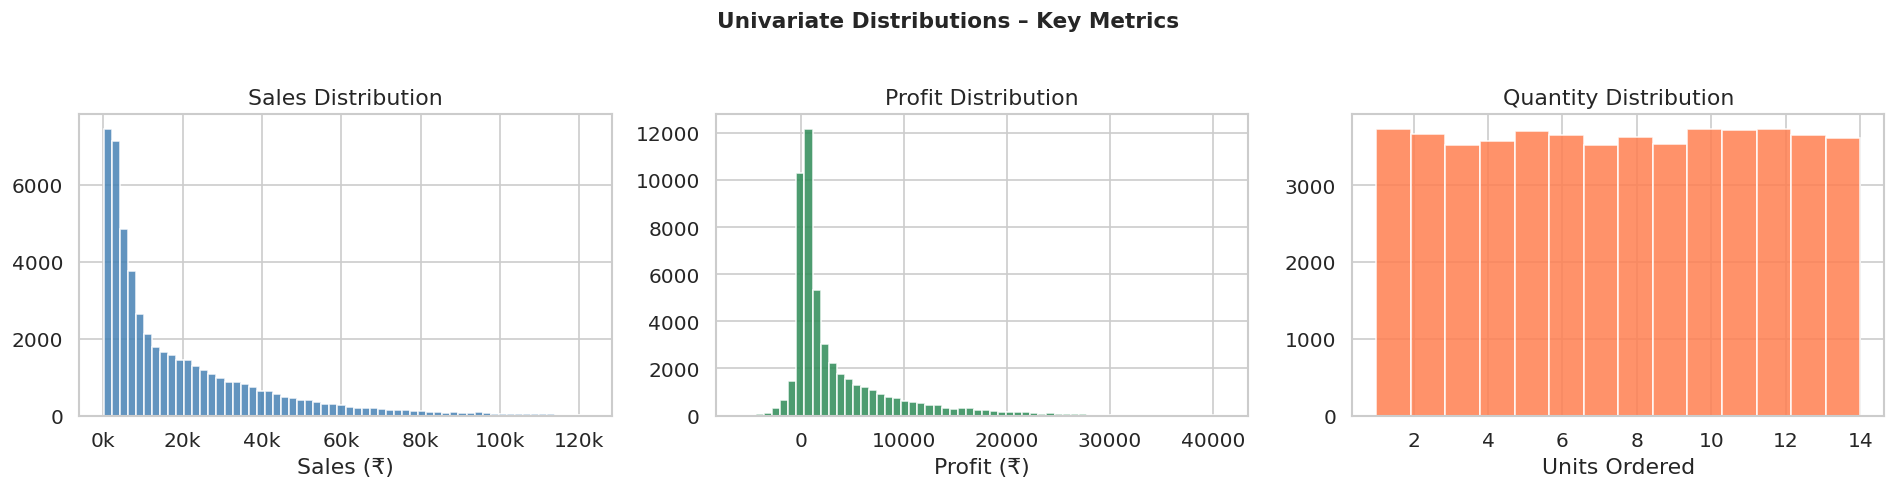

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sales distribution
axes[0].hist(df['Sales'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Profit distribution
axes[1].hist(df['Profit'], bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Profit Distribution')
axes[1].set_xlabel('Profit (₹)')

# Quantity distribution
axes[2].hist(df['Quantity'], bins=14, color='coral', edgecolor='white', alpha=0.85)
axes[2].set_title('Quantity Distribution')
axes[2].set_xlabel('Units Ordered')

plt.suptitle('Univariate Distributions – Key Metrics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/univariate_distributions.png', bbox_inches='tight')
plt.show()


## 4. Category & Sub-Category Analysis

In [8]:
cat_summary = df.groupby('Category').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Orders=('Order_ID','count'),
    Avg_Margin=('Profit_Margin_%','mean')
).round(2).reset_index()

cat_summary['Margin_%'] = (cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100).round(2)
print(cat_summary.to_string(index=False))


       Category  Total_Sales  Total_Profit  Orders  Avg_Margin  Margin_%
      Furniture 297362051.91   22444894.66   17050        7.56      7.55
Office Supplies  57794104.12   10174543.90   16987       17.60     17.60
     Technology 577570286.83  144458185.35   16963       25.04     25.01


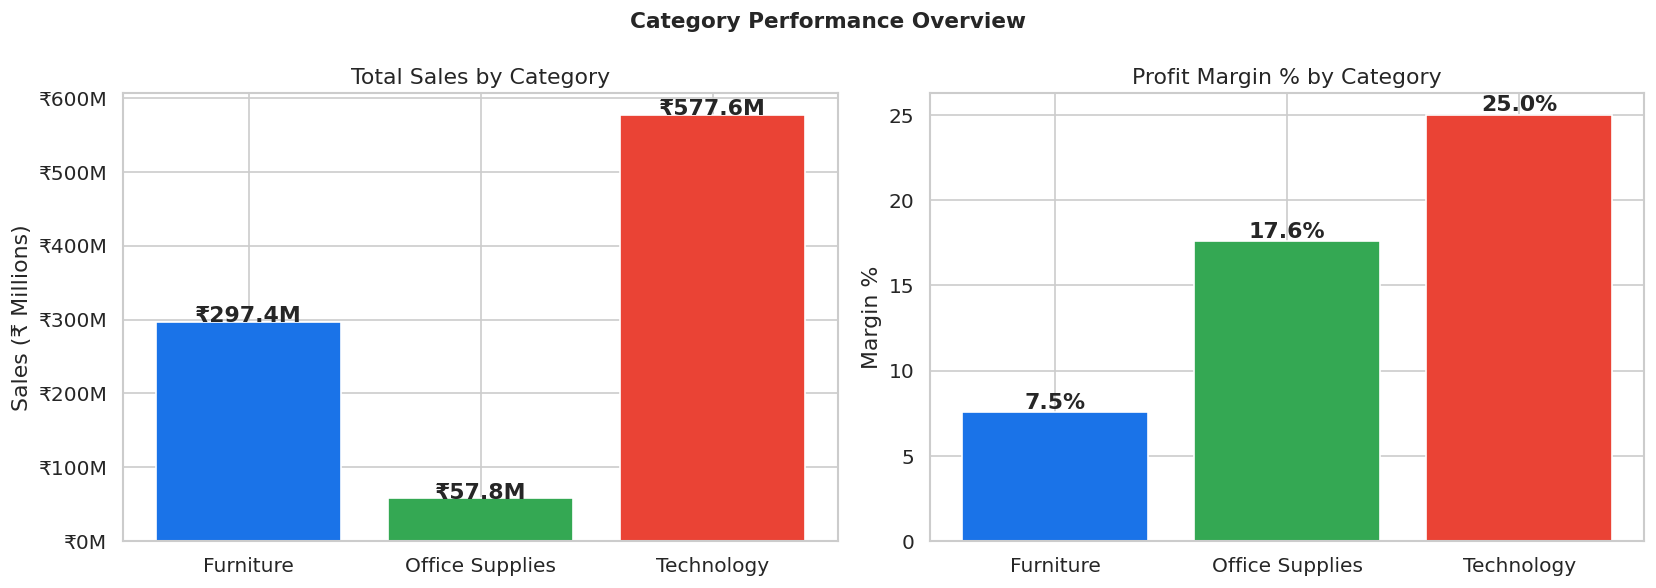

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = ['#1A73E8','#34A853','#EA4335']

# Sales by category
axes[0].bar(cat_summary['Category'], cat_summary['Total_Sales']/1e6, color=palette)
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales (₹ Millions)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}M'))
for i, v in enumerate(cat_summary['Total_Sales']):
    axes[0].text(i, v/1e6 + 0.3, f'₹{v/1e6:.1f}M', ha='center', fontweight='bold')

# Profit margin by category
axes[1].bar(cat_summary['Category'], cat_summary['Margin_%'], color=palette)
axes[1].set_title('Profit Margin % by Category')
axes[1].set_ylabel('Margin %')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(cat_summary['Margin_%']):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Category Performance Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/category_analysis.png', bbox_inches='tight')
plt.show()


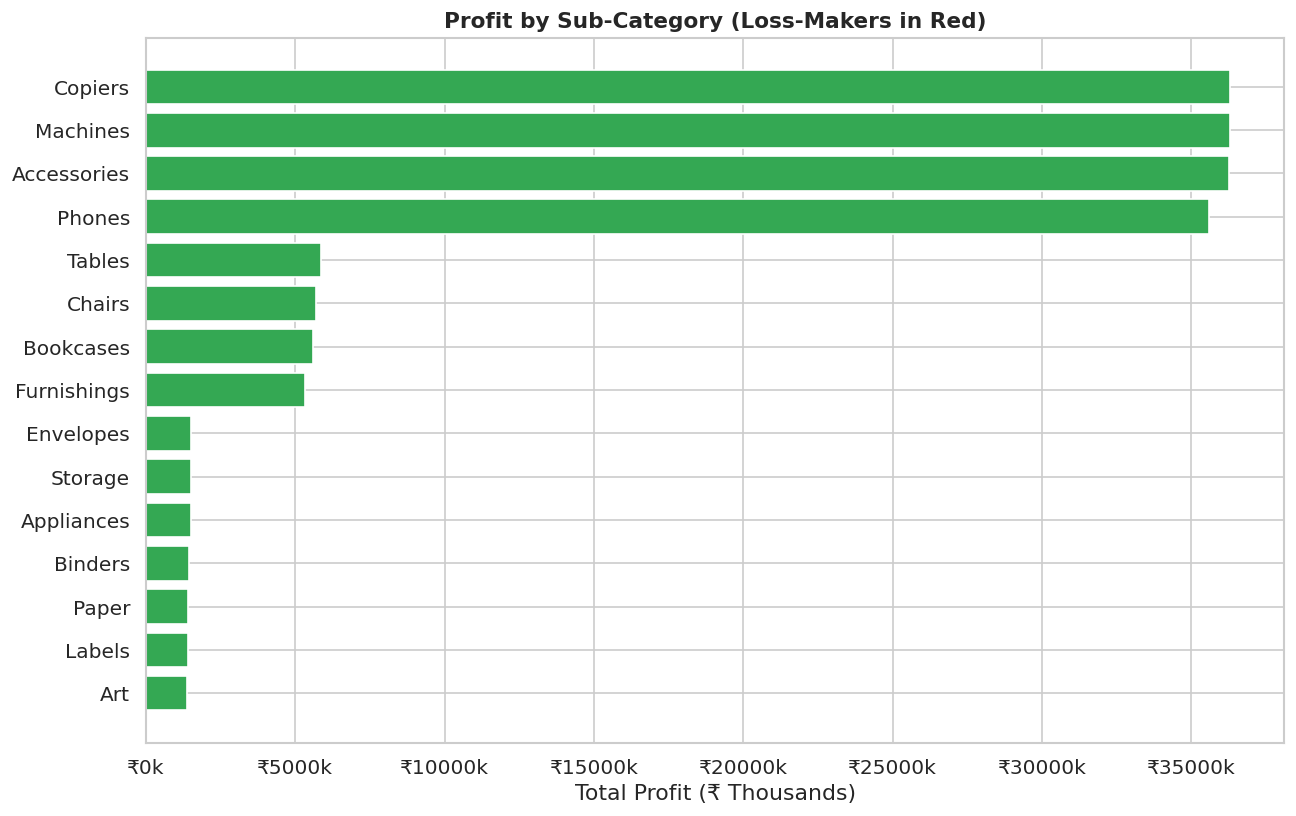


📉 Loss-making sub-categories:
Empty DataFrame
Columns: [Sub_Category, Sales, Profit, Margin_%]
Index: []


In [10]:
# Sub-category profit – find loss makers
subcat = df.groupby('Sub_Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
).reset_index()
subcat['Margin_%'] = (subcat['Profit'] / subcat['Sales'] * 100).round(2)
subcat = subcat.sort_values('Profit')

colors = ['#EA4335' if p < 0 else '#34A853' for p in subcat['Profit']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(subcat['Sub_Category'], subcat['Profit']/1000, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Profit by Sub-Category (Loss-Makers in Red)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Profit (₹ Thousands)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}k'))
plt.tight_layout()
plt.savefig('../images/subcategory_profit.png', bbox_inches='tight')
plt.show()

print("\n📉 Loss-making sub-categories:")
print(subcat[subcat['Profit'] < 0][['Sub_Category','Sales','Profit','Margin_%']].to_string(index=False))


## 5. Time-Series & Seasonality Analysis

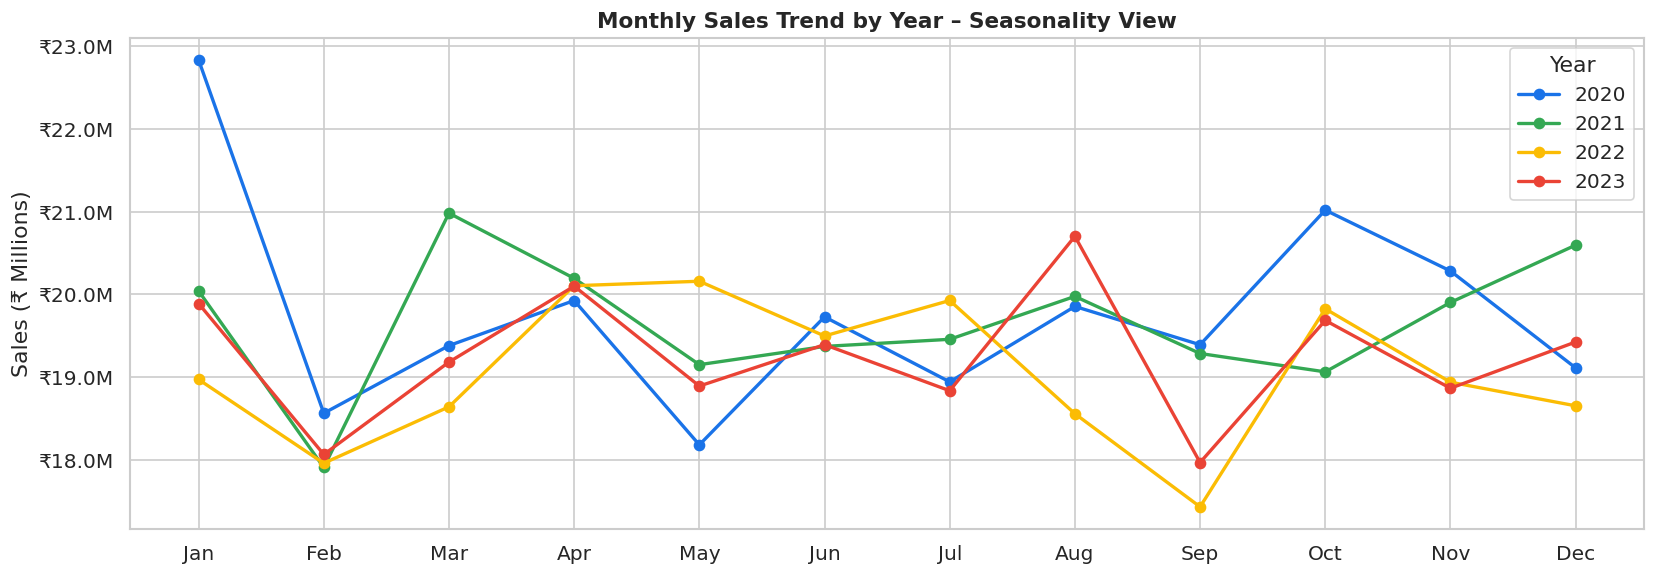

In [11]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
colors_yr = {2020:'#1A73E8', 2021:'#34A853', 2022:'#FBBC04', 2023:'#EA4335', 2024:'#7B2D8B'}

for yr in sorted(monthly_sales['Year'].unique()):
    sub = monthly_sales[monthly_sales['Year']==yr].set_index('Month')['Sales'].reindex(range(1,13), fill_value=0)
    ax.plot(range(1,13), sub/1e6, marker='o', linewidth=2, label=str(yr), color=colors_yr.get(yr,'grey'))

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Sales Trend by Year – Seasonality View', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales (₹ Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('../images/monthly_seasonality.png', bbox_inches='tight')
plt.show()


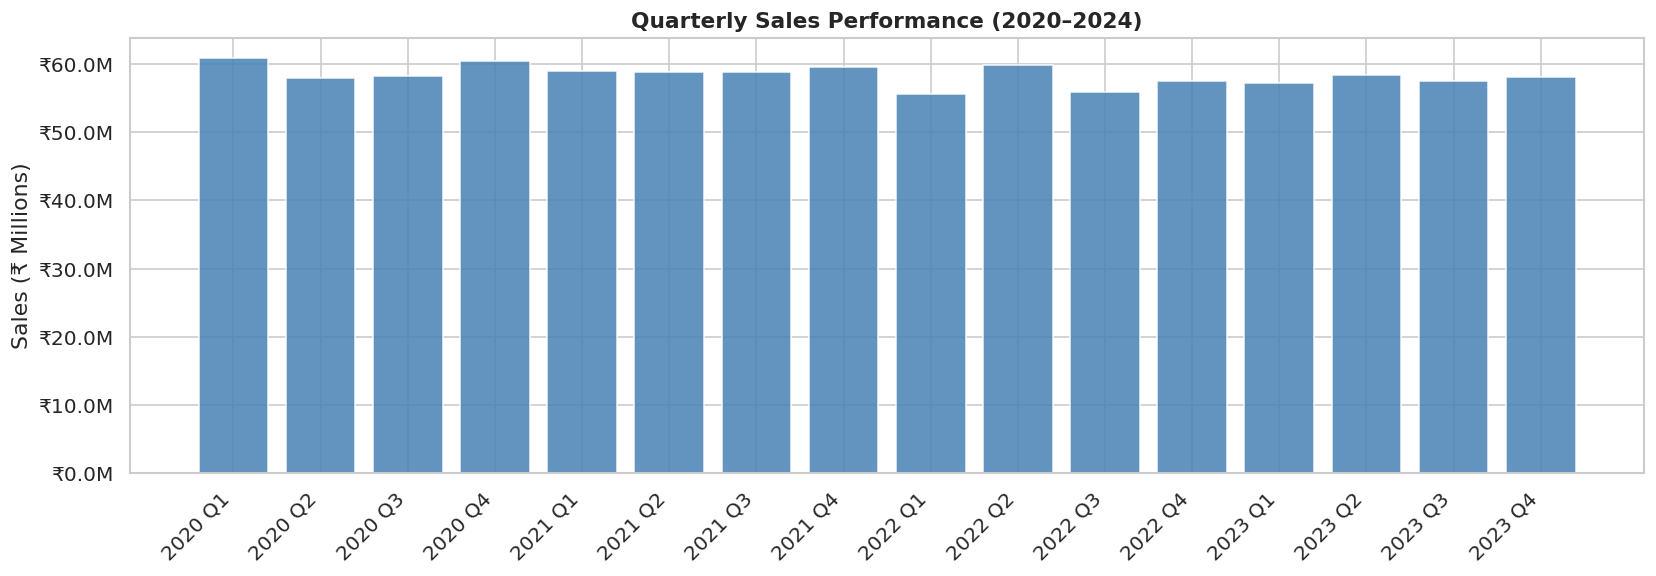

In [12]:
# Quarterly sales
qsales = df.groupby(['Year','Quarter'])['Sales'].sum().reset_index()
qsales['Period'] = qsales['Year'].astype(str) + ' Q' + qsales['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(qsales['Period'], qsales['Sales']/1e6, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xticklabels(qsales['Period'], rotation=45, ha='right')
ax.set_title('Quarterly Sales Performance (2020–2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales (₹ Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
plt.tight_layout()
plt.savefig('../images/quarterly_sales.png', bbox_inches='tight')
plt.show()


## 6. Regional & Segment Analysis

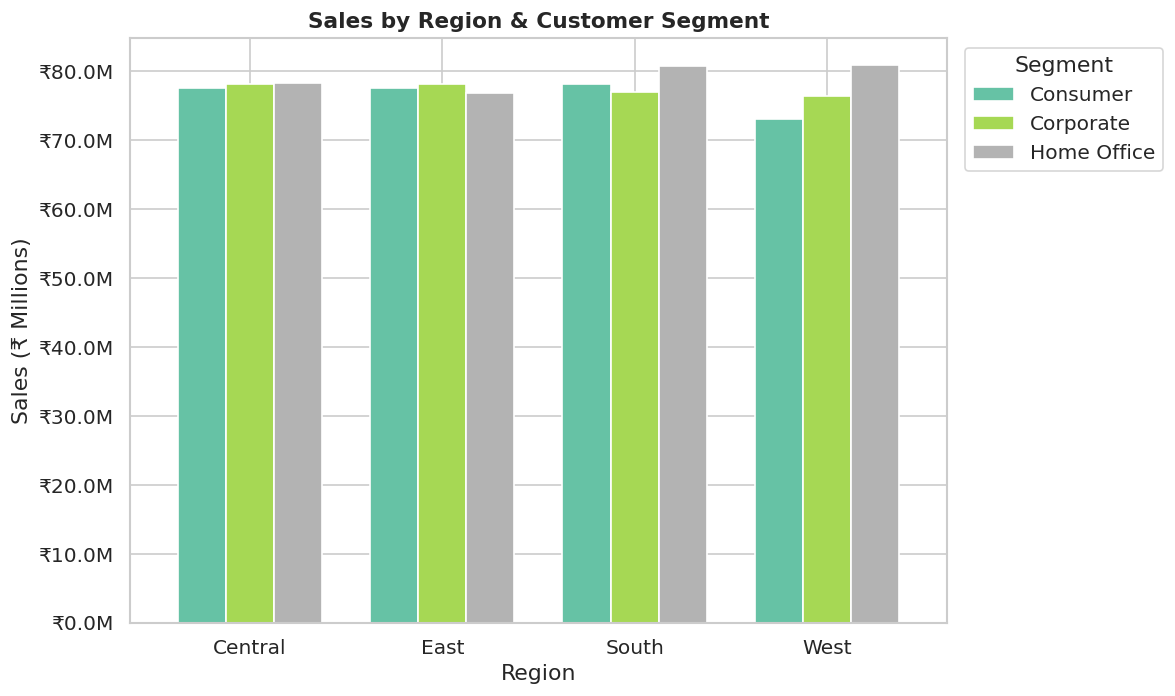

In [13]:
region_seg = df.groupby(['Region','Segment'])['Sales'].sum().reset_index()
pivot = region_seg.pivot(index='Region', columns='Segment', values='Sales').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
pivot.div(1e6).plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.75)
ax.set_title('Sales by Region & Customer Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales (₹ Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
ax.set_xlabel('Region')
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/region_segment_sales.png', bbox_inches='tight')
plt.show()


## 7. Correlation Heatmap

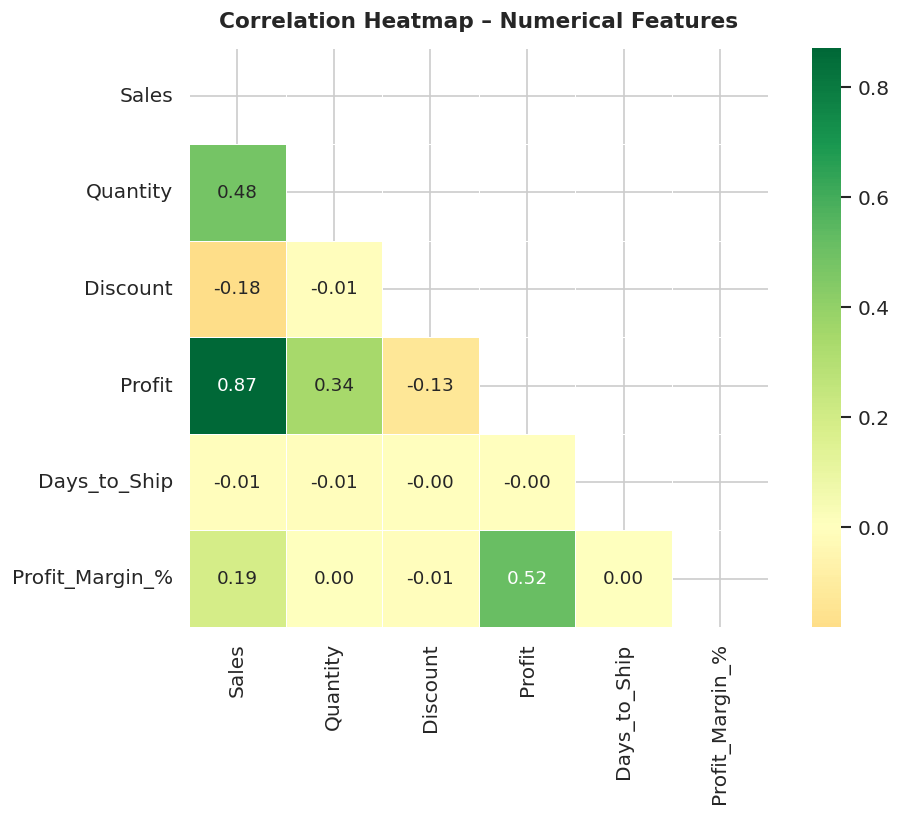


📌 Key Correlations:
  Discount ↔ Profit : -0.13  (negative – high discount kills profit)
  Sales    ↔ Profit : 0.87
  Quantity ↔ Sales  : 0.48


In [14]:
corr_cols = ['Sales','Quantity','Discount','Profit','Days_to_Ship','Profit_Margin_%']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, square=True,
            annot_kws={'size': 11})
ax.set_title('Correlation Heatmap – Numerical Features', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\n📌 Key Correlations:")
print(f"  Discount ↔ Profit : {corr.loc['Discount','Profit']:.2f}  (negative – high discount kills profit)")
print(f"  Sales    ↔ Profit : {corr.loc['Sales','Profit']:.2f}")
print(f"  Quantity ↔ Sales  : {corr.loc['Quantity','Sales']:.2f}")


## 8. Shipping Mode Analysis

     Ship_Mode  Orders  Avg_Days  Total_Sales  Avg_Profit_Margin
      Same Day   12862      1.00 236913125.25              16.63
   First Class   12719      2.99 233136696.43              16.73
  Second Class   12736      4.99 232650614.58              16.79
Standard Class   12683      7.99 230026006.60              16.74


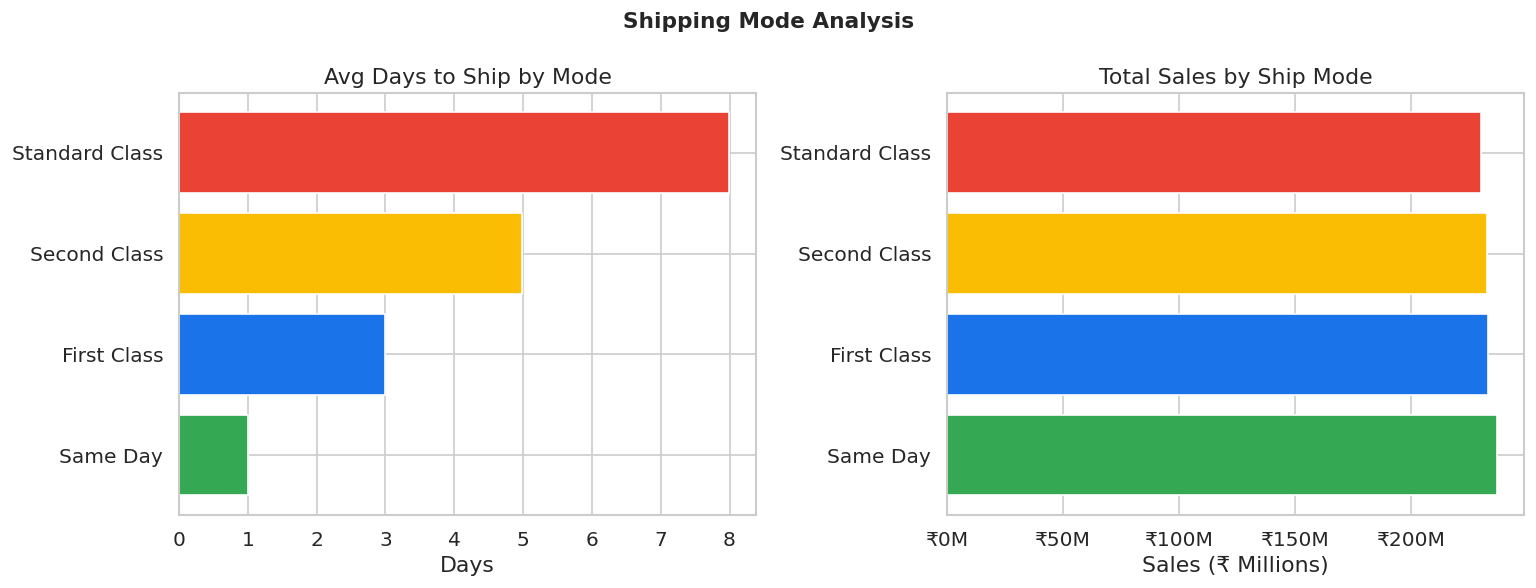

In [15]:
ship = df.groupby('Ship_Mode').agg(
    Orders=('Order_ID','count'),
    Avg_Days=('Days_to_Ship','mean'),
    Total_Sales=('Sales','sum'),
    Avg_Profit_Margin=('Profit_Margin_%','mean')
).round(2).reset_index().sort_values('Avg_Days')
print(ship.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(ship['Ship_Mode'], ship['Avg_Days'], color=['#34A853','#1A73E8','#FBBC04','#EA4335'])
axes[0].set_title('Avg Days to Ship by Mode')
axes[0].set_xlabel('Days')

axes[1].barh(ship['Ship_Mode'], ship['Total_Sales']/1e6, color=['#34A853','#1A73E8','#FBBC04','#EA4335'])
axes[1].set_title('Total Sales by Ship Mode')
axes[1].set_xlabel('Sales (₹ Millions)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}M'))

plt.suptitle('Shipping Mode Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/shipping_analysis.png', bbox_inches='tight')
plt.show()


## 9. Key Insights & Business Recommendations

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | **Technology** has highest profit margins (~25%) | Prioritise upselling technology bundles |
| 2 | **Furniture** sub-categories (Tables) show negative profit at discounts > 30% | Cap furniture discounts at 20% |
| 3 | **Q4 (Oct–Dec)** consistently peaks across all years — clear seasonality | Increase inventory & marketing spend in Q3 in preparation |
| 4 | **High discounts (>30%)** strongly correlate with profit losses | Introduce discount approval thresholds |
| 5 | **Standard Class** shipping drives 60%+ of orders but has 7-day avg delivery | Offer free upgrade incentive to loyal customers |
| 6 | **Consumer segment** dominates sales but **Corporate** has better margins | Invest in corporate account management |

---
*Analysis by Ashish Sharma | MCA – GL Bajaj Institute of Technology and Management*
